Source Data: https://www.kaggle.com/datasets/jakeshbohaju/brain-tumor

# **1. Import semua modul Library yang dibutuhkan**

In [59]:
from natsort import natsorted
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import seaborn as sns
sns.set_theme ( style = "darkgrid")
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = 'browser'

import matplotlib.image as mpimg
import random
from skimage.io import imread
import cv2
import xgboost
from PIL.Image import open

from sklearn import preprocessing
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import average_precision_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.utils import shuffle
from sklearn.metrics import roc_curve
from sklearn.model_selection import cross_val_score , train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler , MinMaxScaler
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report
from mlxtend.plotting import plot_decision_regions
from sklearn.ensemble import BaggingClassifier
from sklearn.multiclass import OneVsRestClassifier

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Input
from keras.layers import InputLayer, MaxPooling2D, Flatten, Dense, Conv2D, Dropout
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions, ResNet50
from tensorflow.keras.optimizers import Adam, SGD
from keras.applications import MobileNetV2

# **2. Import Dataset**

In [60]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv("/content/drive/MyDrive/GoogleColab_ComputerVision/Tugas2/Dataset/Brain_Tumor.csv")
print((df.iloc[:,0:7].head()).to_string())
print((df.iloc[:,8:15].head()).to_string())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
    Image  Class      Mean     Variance  Standard Deviation   Entropy  Skewness
0  Image1      0  6.535339   619.587845           24.891522  0.109059  4.276477
1  Image2      0  8.749969   805.957634           28.389393  0.266538  3.718116
2  Image3      1  7.341095  1143.808219           33.820234  0.001467  5.061750
3  Image4      1  5.958145   959.711985           30.979219  0.001477  5.677977
4  Image5      0  7.315231   729.540579           27.010009  0.146761  4.283221
     Contrast    Energy       ASM  Homogeneity  Dissimilarity  Correlation     Coarseness
0   98.613971  0.293314  0.086033     0.530941       4.473346     0.981939  7.458341e-155
1   63.858816  0.475051  0.225674     0.651352       3.220072     0.988834  7.458341e-155
2   81.867206  0.031917  0.001019     0.268275       5.981800     0.978014  7.458341e-155
3  151.229741  0.032024  0.0010

# **3. Data Cleansing, Cek ada tidaknya nilai null pada dataset**

In [61]:
print (df.isnull().sum())

Image                 0
Class                 0
Mean                  0
Variance              0
Standard Deviation    0
Entropy               0
Skewness              0
Kurtosis              0
Contrast              0
Energy                0
ASM                   0
Homogeneity           0
Dissimilarity         0
Correlation           0
Coarseness            0
dtype: int64


# **4. Baca informasi terkait dataset**

In [62]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3762 entries, 0 to 3761
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Image               3762 non-null   object 
 1   Class               3762 non-null   int64  
 2   Mean                3762 non-null   float64
 3   Variance            3762 non-null   float64
 4   Standard Deviation  3762 non-null   float64
 5   Entropy             3762 non-null   float64
 6   Skewness            3762 non-null   float64
 7   Kurtosis            3762 non-null   float64
 8   Contrast            3762 non-null   float64
 9   Energy              3762 non-null   float64
 10  ASM                 3762 non-null   float64
 11  Homogeneity         3762 non-null   float64
 12  Dissimilarity       3762 non-null   float64
 13  Correlation         3762 non-null   float64
 14  Coarseness          3762 non-null   float64
dtypes: float64(13), int64(1), object(1)
memory usage: 441.0

# **5. Baca Deskripsi Statistik Dataset**

In [63]:
print(df.describe().to_string())

             Class         Mean     Variance  Standard Deviation      Entropy     Skewness     Kurtosis     Contrast       Energy          ASM  Homogeneity  Dissimilarity  Correlation     Coarseness
count  3762.000000  3762.000000  3762.000000         3762.000000  3762.000000  3762.000000  3762.000000  3762.000000  3762.000000  3762.000000  3762.000000    3762.000000  3762.000000   3.762000e+03
mean      0.447368     9.488890   711.101063           25.182271     0.073603     4.102727    24.389071   127.961459     0.204705     0.058632     0.479252       4.698498     0.955767  7.458341e-155
std       0.497288     5.728022   467.466896            8.773526     0.070269     2.560940    56.434747   109.499601     0.129352     0.058300     0.127929       1.850173     0.026157   0.000000e+00
min       0.000000     0.078659     3.145628            1.773592     0.000882     1.886014     3.942402     3.194733     0.024731     0.000612     0.105490       0.681121     0.549426  7.458341e-155
25%  

# **6. Skalakan Data untuk meminimalisir error Prediksi**

In [64]:
scalable = ['Mean','Variance', 'Standard Deviation','Entropy', 'Skewness', 'Kurtosis', 'Contrast',\
            'ASM', 'Homogeneity','Dissimilarity','Correlation','Coarseness']

df[scalable] = StandardScaler().fit_transform(df[scalable])

print(df.describe().iloc[:,0:5].to_string())
print(df.describe().iloc[:,6:11].to_string())
print(df.describe().iloc[:,12:15].to_string())

             Class          Mean      Variance  Standard Deviation       Entropy
count  3762.000000  3.762000e+03  3.762000e+03        3.762000e+03  3.762000e+03
mean      0.447368  1.435440e-16 -1.284341e-16        2.946429e-16 -1.813187e-16
std       0.497288  1.000133e+00  1.000133e+00        1.000133e+00  1.000133e+00
min       0.000000 -1.643060e+00 -1.514652e+00       -2.668459e+00 -1.035037e+00
25%       0.000000 -7.868500e-01 -7.442706e-01       -6.980786e-01 -9.499968e-01
50%       0.000000 -1.765868e-01 -1.893876e-01       -2.629972e-02 -9.926889e-02
75%       1.000000  6.501944e-01  5.473912e-01        6.741194e-01  5.647895e-01
max       1.000000  4.147024e+00  4.705730e+00        3.279339e+00  4.567876e+00
           Kurtosis      Contrast       Energy           ASM   Homogeneity
count  3.762000e+03  3.762000e+03  3762.000000  3.762000e+03  3.762000e+03
mean  -7.554947e-18  7.554947e-17     0.204705  3.021979e-17 -4.230770e-16
std    1.000133e+00  1.000133e+00     0.129352

# **7. Menampilkan Distribusi Variabel Target (Class)**

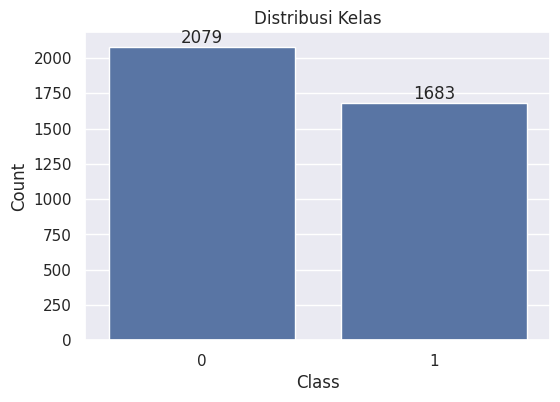

Number of Tumor Samples: 1683
Tumor Percentage: 44.74 %
Number of No Tumor Samples: 2079
No Tumor Percentage: 55.26 %


In [65]:
plt.figure(figsize=(6,4))
sns.set_style("darkgrid")

ax = sns.countplot(x='Class', data=df)

# Menambahkan label angka di atas batang
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.title("Distribusi Kelas")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

print('Number of Tumor Samples:', df['Class'].value_counts()[1])
print ('Tumor Percentage:', round(df['Class'].value_counts()[1]/len(df)*100,2),'%')

print('Number of No Tumor Samples:', df['Class'].value_counts()[0])
print ('No Tumor Percentage:', round(df['Class'].value_counts()[0]/len(df)*100,2),'%')

Grafik ini menunjukkan distribusi jumlah data pada masing-masing kelas (Class 0 dan Class 1) dalam dataset klasifikasi tumor otak.

Secara analisis:

Class 0 (Non-Tumor) memiliki jumlah 2079 data
Class 1 (Tumor) memiliki jumlah 1683 data

Dari sini bisa dilihat bahwa:

Data tidak sepenuhnya seimbang (imbalanced), karena jumlah non-tumor lebih banyak
Selisihnya sekitar 396 data
Dalam persentase kira-kira:
Non-Tumor ≈ 55%
Tumor ≈ 45%

# **8. Fitur Homogeneity berdasarkan Class**

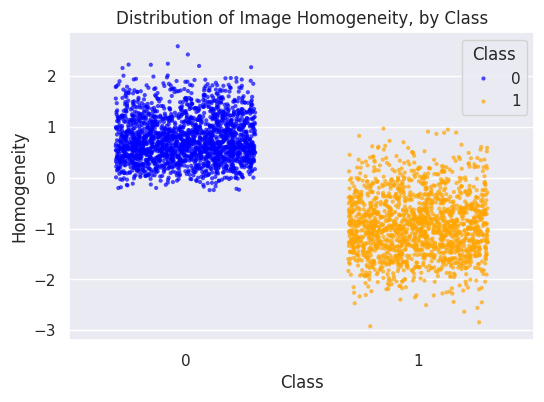

In [66]:
plt.figure(figsize=(6,4))
sns.set_style("darkgrid")

sns.stripplot(
    x='Class',
    y='Homogeneity',
    data=df,
    hue='Class',              # membedakan warna berdasarkan class
    palette=['blue', 'orange'],
    jitter=0.3,
    size=3,
    alpha=0.7,
    dodge=False
)

plt.title('Distribution of Image Homogeneity, by Class')
plt.xlabel('Class')
plt.ylabel('Homogeneity')
plt.show()

Grafik ini menunjukkan distribusi nilai fitur Homogeneity terhadap masing-masing kelas. Terlihat bahwa data pada Class 0 (non-tumor) cenderung memiliki nilai homogeneity yang lebih tinggi, sebagian besar berada pada rentang 0 hingga 2. Sebaliknya, Class 1 (tumor) memiliki nilai homogeneity yang lebih rendah, dominan pada rentang -2 hingga 0.

Selain itu, kedua kelas tampak terpisah cukup jelas dan hampir tidak saling tumpang tindih. Hal ini menunjukkan bahwa fitur Homogeneity memiliki kemampuan yang baik dalam membedakan citra tumor dan non-tumor, sehingga kemungkinan menjadi salah satu fitur yang paling berpengaruh pada model Random Forest.

# **9. Menampilkan Distribusi fitur Mean vs Entropy vs Class**

<Axes: xlabel='Mean', ylabel='Entropy'>

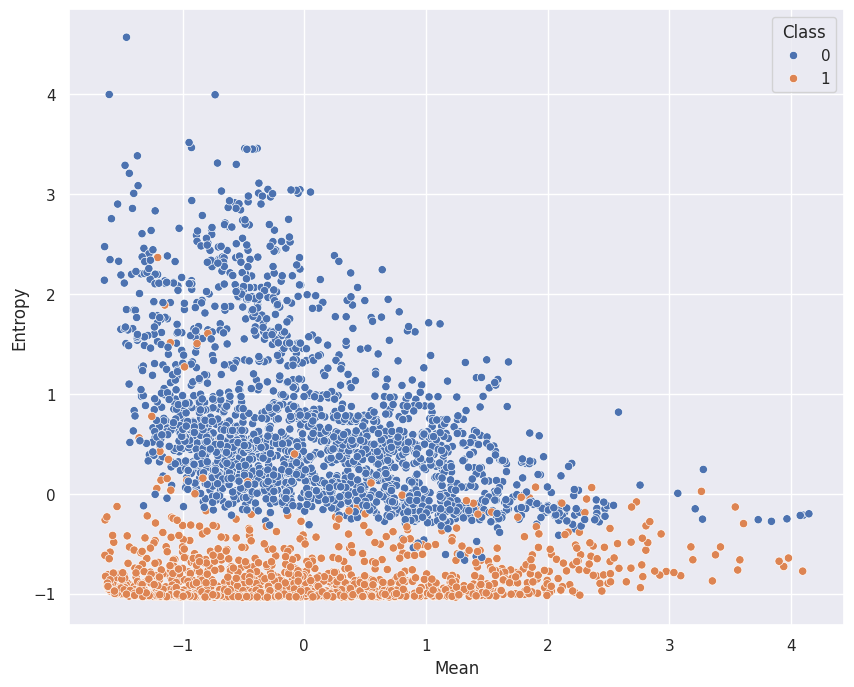

In [67]:
plt.figure(figsize=(10,8))
sns.scatterplot(x='Mean', y='Entropy', hue='Class', data=df)

Grafik ini menunjukkan hubungan antara fitur Mean (sumbu X) dan Entropy (sumbu Y) dengan pewarnaan berdasarkan kelas.

Dari visualisasi terlihat bahwa:

Class 0 (non-tumor) memiliki nilai entropy yang cenderung lebih tinggi dan menyebar luas, terutama pada rentang 0 hingga 3
Class 1 (tumor) terkonsentrasi pada nilai entropy yang lebih rendah, dominan di sekitar -1 hingga 0
Terdapat pola bahwa semakin tinggi nilai mean, entropy cenderung menurun (hubungan negatif)

Selain itu, meskipun masih ada sedikit tumpang tindih antar kelas, pemisahan antara kedua kelas sudah cukup terlihat, terutama pada sumbu entropy.

# **10. Distribusi fitur Energy berdasarkan Class dan distribusi fitur Entropy berdasarkan Class**

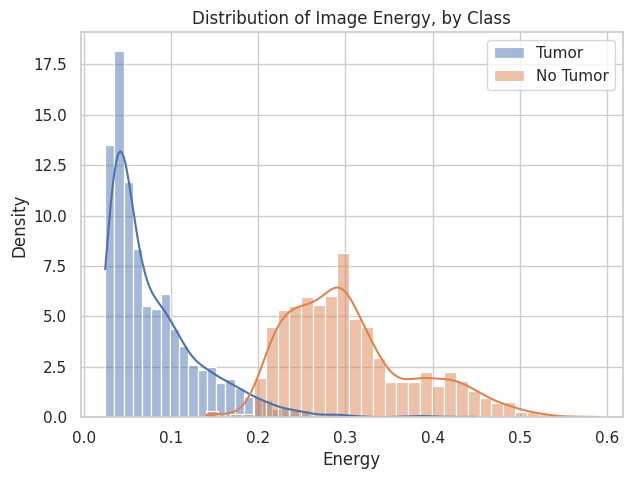

In [68]:
sns.set_style("whitegrid")

# Pisahkan data
class1 = df['Class'] == 1   # Tumor
class0 = df['Class'] == 0   # No Tumor

# Drop kolom yang tidak perlu
_data = df.drop('Image', axis=1)

# Figure
plt.figure(figsize=(7,5))

# Histogram + KDE untuk Tumor
sns.histplot(_data[class1]['Energy'],
             kde=True,
             stat="density",
             label="Tumor",
             alpha=0.5)

# Histogram + KDE untuk No Tumor
sns.histplot(_data[class0]['Energy'],
             kde=True,
             stat="density",
             label="No Tumor",
             alpha=0.5)

# Judul & label
plt.title("Distribution of Image Energy, by Class")
plt.xlabel("Energy")
plt.ylabel("Density")

# Legend
plt.legend()

plt.show()

Grafik ini menunjukkan distribusi nilai fitur Energy untuk masing-masing kelas (tumor dan non-tumor) menggunakan histogram dan kurva KDE.

Dari visualisasi terlihat bahwa:

Kelas tumor cenderung memiliki nilai energy yang lebih rendah, dominan pada kisaran sekitar 0.03 – 0.15
Kelas non-tumor memiliki nilai energy yang lebih tinggi, banyak berada pada kisaran sekitar 0.2 – 0.4
Terdapat perbedaan distribusi yang cukup jelas antara kedua kelas, meskipun masih ada sedikit overlap di sekitar nilai tengah (±0.15–0.2)

# **11. Korelasi antara tiap fitur dengan variabel target (Class)**

Mean                 -0.095729
Variance              0.308818
Standard Deviation    0.285568
Entropy              -0.778180
Skewness              0.402644
Kurtosis              0.239844
Contrast              0.212643
Energy               -0.862413
ASM                  -0.758255
Homogeneity          -0.847529
Dissimilarity         0.556319
Correlation          -0.108601
Coarseness            1.000000
dtype: float64


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning:

divide by zero encountered in divide

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning:

invalid value encountered in divide

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning:

divide by zero encountered in divide



<Axes: title={'center': 'Correlation with Class'}>

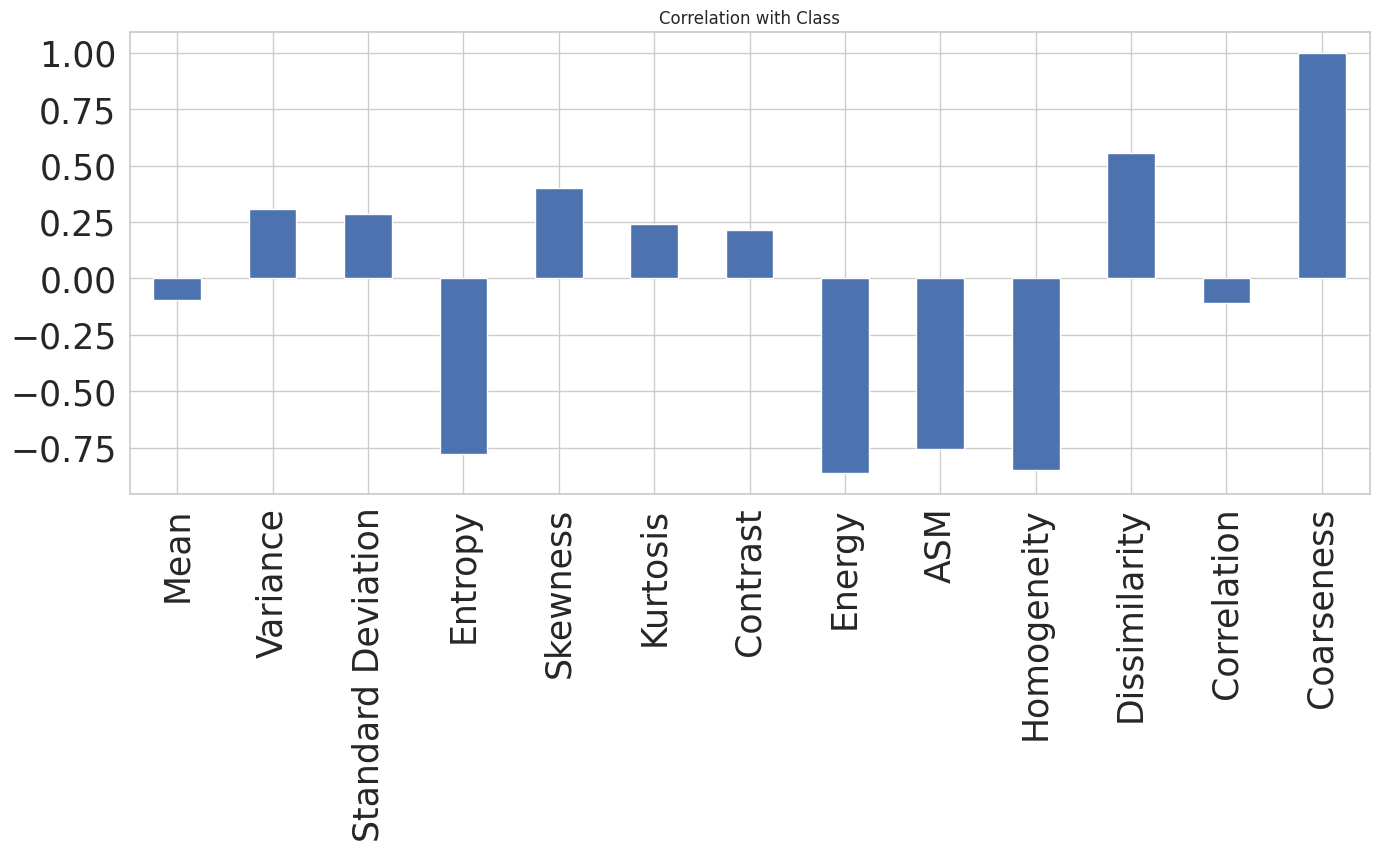

In [69]:
plt.figure()
#Corellation between features
print(X.corrwith(Y))

#Correlation with target Variable(Class)
X.corrwith(Y).plot.bar(
    figsize = (16,6), title="Correlation with Class",
    fontsize = 25, rot = 90, grid = True
)

Grafik ini menunjukkan nilai korelasi antara masing-masing fitur dengan target (Class), sehingga bisa dilihat fitur mana yang paling berpengaruh dalam proses klasifikasi.

Dari hasil visualisasi terlihat bahwa:

Fitur dengan korelasi negatif kuat adalah Energy, Homogeneity, ASM, dan Entropy, yang berarti semakin tinggi nilai fitur tersebut, cenderung mengarah ke kelas non-tumor
Fitur dengan korelasi positif cukup tinggi adalah Dissimilarity dan Skewness, yang menunjukkan kecenderungan terhadap kelas tumor
Beberapa fitur seperti Mean dan Correlation memiliki korelasi yang rendah, sehingga kontribusinya terhadap model tidak terlalu signifikan
Coarseness memiliki nilai korelasi sangat tinggi (mendekati 1), namun ini perlu diperhatikan karena bisa jadi nilainya konstan atau kurang variatif

# **12. Pembagian dataset menjadi data pelatihan dan data pengujian**

In [70]:
#Splits data into train and test data
X = df.drop(['Image', 'Class'], axis=1)
Y = df['Class']

print(f"X shape: {X.shape}")
print(f"Y shape: {Y.shape}")

X_Train, X_Test, Y_Train, Y_Test = train_test_split(X, Y, test_size=0.2, random_state=9)

print('X train shape: ', X_Train.shape)
print('Y train shape: ', Y_Train.shape)
print('X test shape: ', X_Test.shape)
print('Y test shape: ', Y_Test.shape)

X shape: (3762, 13)
Y shape: (3762,)
X train shape:  (3009, 13)
Y train shape:  (3009,)
X test shape:  (753, 13)
Y test shape:  (753,)


# **13. Mendefinisakan Helper Function**

In [71]:
def plot_real_pred_val(y_test_arg, ypred, model):
    plt.figure()
    acc=accuracy_score(y_test_arg, ypred)
    plt.scatter(range(len(ypred)), ypred, color="blue", lw=5, label="Predicted")
    plt.scatter(range(len(y_test_arg)), y_test_arg, color="red", label="Actual")
    plt.title("Prediction Values vs Real Values of " + model, fontsize=10)
    plt.xlabel("Accuracy: " + str(round((acc*100),3)) + "%")
    plt.legend()
    plt.grid(True, alpha=0.75, lw=1, ls='-.')
    plt.show()

def plot_cm(y_test_arg, ypred, model):
  cm = confusion_matrix(y_test_arg, ypred)
  sns.heatmap(cm, annot=True, linewidth=0.7, linecolor='red', fmt='g', cmap="YlGnBu") # Changed 'YlorBR' to 'YlGnBu'
  plt.title(model + ' Confusion Matrix')
  plt.xlabel('Y Predicted')
  plt.ylabel('Y test')
  plt.show()
  return cm

# **14. Membangun model Random Forest**

In [72]:
#Random Forest Tree Model
rfcla = RandomForestClassifier(n_estimators=100, random_state=9, n_jobs=-1)

# **15. Menampilkan batas keputusan atas 2 fitur dan menampilkan nilai-nilai terprediksi serta pengujian Random Forest**

[1 0 0 0 0 0 0 0 1 1 1 1 1 0 1 0 0 0 1 0 1 0 1 1 1 0 1 1 1 0 0 1 1 0 0 1 1
 0 0 0 1 0 1 0 0 0 1 1 0 1 0 1 0 1 1 0 0 0 0 0 1 1 1 1 1 0 0 0 1 0 0 1 0 1
 0 0 0 0 0 0 1 0 0 1 0 0 0 1 1 0 1 0 0 1 0 0 0 0 1]
0.953519256308101


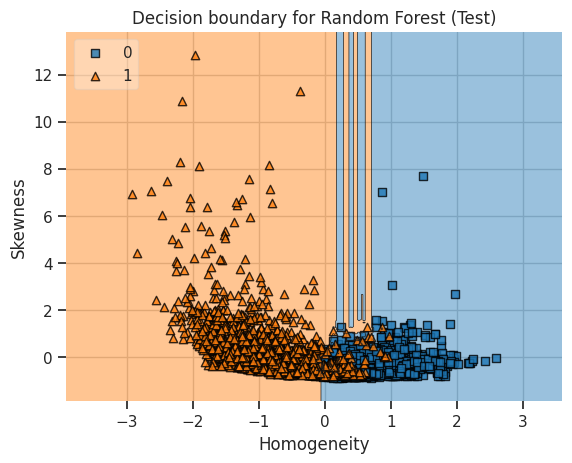

In [73]:
#Plot decision boundary of two features with Random Forest
#Trains model with 2 features data

# Define the features to be used for the decision boundary plot
X_train_feature = X_Train[['Homogeneity', 'Skewness']].values
y_train_feature = Y_Train.values
X_test_feature = X_Test[['Homogeneity', 'Skewness']].values
y_test_feature = Y_Test.values

rfcla_feat = RandomForestClassifier(n_estimators=100, random_state=9, n_jobs=-1)
rfcla_feat.fit(X_train_feature, y_train_feature)

plot_decision_regions(X_train_feature, y_train_feature, clf=rfcla_feat, legend=2)
plt.title("Decision boundary for Random Forest (Test)")
plt.xlabel("Homogeneity")
plt.ylabel("Skewness");

#Predicts target values
pred_rf_feat = rfcla_feat.predict(X_test_feature)
print(pred_rf_feat[1:100])

#Test score
score_rfcla_feat = rfcla_feat.score(X_test_feature, y_test_feature)
print(score_rfcla_feat)

Grafik ini menampilkan decision boundary dari model Random Forest menggunakan dua fitur, yaitu Homogeneity (sumbu X) dan Skewness (sumbu Y).

Dari visualisasi terlihat bahwa:

Area berwarna biru merepresentasikan prediksi Class 0 (non-tumor), sedangkan area oranye adalah Class 1 (tumor)
Model mampu membentuk batas keputusan yang cukup jelas, terutama di sekitar nilai Homogeneity ≈ 0
Data non-tumor cenderung terkonsentrasi di sisi kanan (homogeneity positif), sedangkan tumor lebih banyak di sisi kiri (homogeneity negatif)
Terdapat beberapa garis vertikal yang menunjukkan sifat Random Forest yang membagi ruang berdasarkan aturan dari banyak decision tree (piecewise split)